In [1]:
%config InlineBackend.figure_formats = ['svg']
import sys
from pathlib import Path
import os
ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if Path.cwd().resolve() != ROOT:
    os.chdir(ROOT)
import quimb.tensor as qtn
import cotengra as ctg


import pepsy.linalg_registrations as linalg_registrations
import pepsy.core as core
import pepsy.boundary_states as boundary_states
# import pepsy.boundary_sweeps as boundary_sweeps
import quf

In [2]:
linalg_registrations.reg_complex_svd()
import torch

to_backend = core.backend_torch(device="cpu", dtype=torch.complex128, requires_grad=False)

# import jax
# import jax.numpy as jnp

# to_backend = core.backend_jax(dtype=jnp.float64, device=jax.devices("cpu")[0])




opt = core.build_optimizer(progbar=True)

In [3]:
Lx, Ly = (7, 6)
p = qtn.PEPS.rand(Lx=Lx, Ly=Ly, bond_dim=2, seed=66, dtype="complex128")
p = qtn.PEPO.rand(Lx=Lx, Ly=Ly, bond_dim=3, seed=66, dtype="complex128")




pepo = qtn.PEPO.rand(Lx=Lx, Ly=Ly, bond_dim=2, seed=12, dtype="complex128")
pepo.add_tag('PEPO')


re_inds = { indx:qtn.rand_uuid() for indx in p.inner_inds()}
ph = p.conj()
ph.reindex_( re_inds )

# pepsh.reindex_( {idx: qtn.rand_uuid() for idx in pepsh.inner_inds()} )

p.add_tag('KET')
ph.add_tag("BRA")

# ph.reindex_( { f"k{i},{j}":f"b{i},{j}" for i in range(Lx) for j in range(Ly)} )
#norm = ph | pepo | p

norm = ph | p

norm.apply_to_arrays(to_backend)


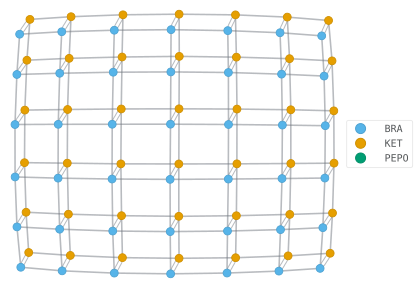

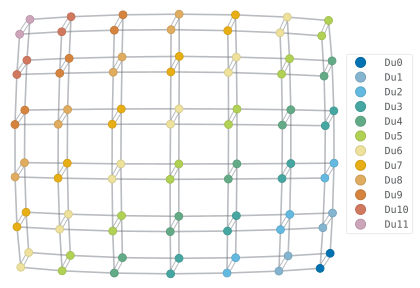

In [4]:
norm.draw(["BRA", "KET", "PEPO"])
norm.draw([ f"Du{i}" for i in range(Ly + Lx - 1) ])

In [5]:
# # normalize norm!
# norm_ = norm.contract(all, optimize=opt)
# norm = norm * (norm_**-1.)
# norm_ = norm.contract(all, optimize=opt)
# norm_

In [6]:
# norm_ = norm.contract(all, optimize=opt)
# norm_

In [7]:
bdy_mps = boundary_states.BdyMPS(tn_flat=p, 
                              opt=opt, 
                              chi=20, 
                              tn_double=norm, 
                              to_backend=to_backend, 
                              single_layer=False)
mps_boundaries = bdy_mps.mps_b





In [8]:
bdy_mps.show("Y4_l")


grid cut=Y4 (direction=y, side=left)
Y5  o--o--o--o--o--o--o
    |  |  |  |  |  |  |
Y4  ●>>●>>●>>●>>●>>●>>●
    |  |  |  |  |  |  |
Y3  o--o--o--o--o--o--o
    |  |  |  |  |  |  |
Y2  o--o--o--o--o--o--o
    |  |  |  |  |  |  |
Y1  o--o--o--o--o--o--o
    |  |  |  |  |  |  |
Y0  o--o--o--o--o--o--o
    X0 X1 X2 X3 X4 X5 X6

│9│20│20│20│20│9│
>─>──>──>──>──>─●
│ │  │  │  │  │ │


MatrixProductState(tensors=7, indices=20, L=7, max_bond=20)

In [9]:
bdy_mps.show("Y4_r")

grid cut=Y1 (direction=y, side=right)
Y5  o--o--o--o--o--o--o
    |  |  |  |  |  |  |
Y4  o--o--o--o--o--o--o
    |  |  |  |  |  |  |
Y3  o--o--o--o--o--o--o
    |  |  |  |  |  |  |
Y2  o--o--o--o--o--o--o
    |  |  |  |  |  |  |
Y1  ●<<●<<●<<●<<●<<●<<●
    |  |  |  |  |  |  |
Y0  o--o--o--o--o--o--o
    X0 X1 X2 X3 X4 X5 X6

│9│20│20│20│20│9│
>─>──>──>──>──>─●
│ │  │  │  │  │ │


MatrixProductState(tensors=7, indices=20, L=7, max_bond=20)

In [10]:
bdy_mps.show("Y2_r")

grid cut=Y3 (direction=y, side=right)
Y5  o--o--o--o--o--o--o
    |  |  |  |  |  |  |
Y4  o--o--o--o--o--o--o
    |  |  |  |  |  |  |
Y3  ●<<●<<●<<●<<●<<●<<●
    |  |  |  |  |  |  |
Y2  o--o--o--o--o--o--o
    |  |  |  |  |  |  |
Y1  o--o--o--o--o--o--o
    |  |  |  |  |  |  |
Y0  o--o--o--o--o--o--o
    X0 X1 X2 X3 X4 X5 X6

│9│20│20│20│20│9│
>─>──>──>──>──>─●
│ │  │  │  │  │ │


MatrixProductState(tensors=7, indices=20, L=7, max_bond=20)

In [11]:
bdy_mps.show("X4_r")

grid cut=X2 (direction=x, side=right)
Y5  o--o--●--o--o--o--o
    |  |  ^  |  |  |  |
Y4  o--o--●--o--o--o--o
    |  |  ^  |  |  |  |
Y3  o--o--●--o--o--o--o
    |  |  ^  |  |  |  |
Y2  o--o--●--o--o--o--o
    |  |  ^  |  |  |  |
Y1  o--o--●--o--o--o--o
    |  |  ^  |  |  |  |
Y0  o--o--●--o--o--o--o
    X0 X1 X2 X3 X4 X5 X6

│9│20│20│20│9│
>─>──>──>──>─●
│ │  │  │  │ │


MatrixProductState(tensors=6, indices=17, L=6, max_bond=20)

In [12]:
bdy_mps.show("D3_l")

grid cut=Du3 (direction=diag, side=left)
Y5  o--o--o--o--o--o--o
    |  |  |  |  |  |  |
Y4  o--o--o--o--o--o--o
    |  |  |  |  |  |  |
Y3  ●--o--o--o--o--o--o
    |↖ |  |  |  |  |  |
Y2  o--●--o--o--o--o--o
    |  |↖ |  |  |  |  |
Y1  o--o--●--o--o--o--o
    |  |  |↖ |  |  |  |
Y0  o--o--o--●--o--o--o
    X0 X1 X2 X3 X4 X5 X6

│20│20│20│
>──>──>──●
│  │  │  │


MatrixProductState(tensors=4, indices=19, L=4, max_bond=20)

In [13]:
bdy_mps.show("D4_r")

grid cut=Du7 (direction=diag, side=right)
Y5  o--o--●--o--o--o--o
    |  |  |↘ |  |  |  |
Y4  o--o--o--●--o--o--o
    |  |  |  |↘ |  |  |
Y3  o--o--o--o--●--o--o
    |  |  |  |  |↘ |  |
Y2  o--o--o--o--o--●--o
    |  |  |  |  |  |↘ |
Y1  o--o--o--o--o--o--●
    |  |  |  |  |  |  |
Y0  o--o--o--o--o--o--o
    X0 X1 X2 X3 X4 X5 X6

│20│20│20│20│
>──>──>──>──●
│  │  │  │  │


MatrixProductState(tensors=5, indices=24, L=5, max_bond=20)